In [53]:
from swo_validation_2023_09_14 import output_dir, default_config
from misc_utils import read_jsonl_to_df, column_to as to
import seaborn as sns
import matplotlib.pyplot as plt
from kagome_round import get_kagome27, get_kagome36
from heisenberg_hamiltonians import HeisenbergJ1J2
from vmc_amplitude import LogProbDenseNet
import torch
import numpy as np
import pandas as pd

In [2]:
default_config

{'n_samples': 5000,
 'energy_baseline': 10.0,
 'lattice_name': 'kagome27',
 'epochs': 100,
 'reset_network': False,
 'net': 'LogProbDenseNet',
 'use_symmetries': True,
 'power_iterations': 50,
 'early_stop': False,
 'resample_every': 1,
 'snapshot_each': None}

In [8]:
set(default_config.keys())-set(read_jsonl_to_df(output_dir.glob("./*/overlaps.jsonl")).columns)

set()

In [3]:
overlaps_df = read_jsonl_to_df(output_dir.glob("./*/overlaps.jsonl")) #.fillna(value=default_config)
losses_df = read_jsonl_to_df(output_dir.glob("./*/losses.jsonl")) #.fillna(value=default_config)

In [75]:
overlaps_df.groupby(['lattice', 'n_samples', 'epochs', 'n_spins', 'energy_baseline', 'net'])['iteration'].max()

lattice                                                                                                                                                                              n_samples  epochs  n_spins  energy_baseline  net                 
KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291  5000       1       36       250.0            LogProbDenseNet         499
                                                                                                                                                                                                10      36       250.0            LogProbDenseNet         499
                                                                                                                                                                                                                 1000.0           LogProbDenseNet    

In [76]:
# sns.relplot(
#     losses_df.query('n_spins == 24 and iteration < 5 and epochs == 100').melt(
#         id_vars=["iteration", "epoch", "global_epoch", "energy_baseline", "epochs", "reset_network", "n_spins", "net"],
#         value_vars=["loss_train", "loss_validation"],
#         value_name="loss",
#     ),
#     x="global_epoch",
#     y="loss",
#     hue="variable",
#     kind="line",
#     row="energy_baseline",
#     col='net'
# ).set(yscale='log')

In [77]:
overlaps_df.query("not use_symmetries")[['n_samples', 'epochs']]

,n_samples,epochs
0,5000,10
1,5000,10
2,5000,10
3,5000,10
4,5000,10
...,...,...
4398,5000,10
4399,5000,10
4400,5000,10
4401,5000,10


In [78]:
overlaps_df.describe(include=['O'])

,alpha,mode,lattice,net,lattice_name
count,0,5004,5004,5004,5004
unique,0,1,4,2,2
top,NaN,power,KagomeLattice12x12_isotropic_factor_149-150-15...,LogProbDenseNet,kagome36
freq,NaN,5004,4148,4748,4047


In [79]:
def describe(df):
    df_ = df.select_dtypes(exclude=['int', 'float'])
    for col in df_.columns:
        print(col)
        for value in df_[col].unique():
            print(f"  - {value}")
    df_ = df.select_dtypes(include=['int', 'float'])
    for col in df_.columns:
        print(col)
        print(f"  : [{df_[col].min():.3f}\t{df_[col].mean():.3f}\t{df_[col].max():.3f}]")
     

In [80]:
describe(overlaps_df)

alpha
  - None
mode
  - power
lattice
  - KagomeLattice2x4
  - KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291
  - KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258
  - KagomeLattice2x5
reset_network
  - False
net
  - LogProbDenseNet
  - SplitGroupResConvNet
use_symmetries
  - False
  - True
lattice_name
  - kagome27
  - kagome36
early_stop
  - False
  - True
iteration
  : [0.000	204.109	499.000]
initial_ground_state_overlap_test
  : [0.185	0.706	0.862]
new_ground_state_overlap_test
  : [0.078	0.642	0.862]
run
  : [0.000	0.000	0.000]
n_samples
  : [5000.000	8996.803	25000.000]
energy_baseline
  : [10.000	451.607	1000.000]
n_spins
  : [24.000	34.341	36.000]
epochs
  : [1.000	216.145	1000.000]
epoch
  : [0.000	6.368	49.000]
power_iterations
  : [50.000	413.939	500.0

In [81]:
def concat_columns(columns):
    def wrapper(df):
        return df[columns].apply(lambda x: "_".join(map(str, x)), axis=1)
    return wrapper

In [82]:
concat_columns(['n_samples', 'epochs', 'n_spins'])(overlaps_df)

0       5000_10_24
1       5000_10_24
2       5000_10_24
3       5000_10_24
4       5000_10_24
           ...    
4999    5000_10_27
5000    5000_10_27
5001    5000_10_27
5002    5000_10_27
5003    5000_10_27
Length: 5004, dtype: object

In [83]:
params = [
    "n_spins",
    "n_samples",
    "energy_baseline",
    "epochs",
    "net",
    "reset_network",
    "use_symmetries",
    "resample_every",
]

In [84]:
# 
# sns.relplot(
#     data=overlaps_df
#     .assign(
#         initial_ground_state_overlap_test_smoothed=lambda df: df.groupby(
#             params
#         )["initial_ground_state_overlap_test"].transform(
#             lambda x: x.rolling(window=1, center=True).mean()
#         ),
#         params=concat_columns(params),
#     ),
#     #.pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
#     x="iteration",
#     y="initial_ground_state_overlap_test_smoothed",
#     # col="epochs",
#     # row="energy_baseline",
#     # hue="net_epochs",
#     kind="line",
#     col="params",
#     col_wrap=4
# )

In [85]:
describe(overlaps_df.query("n_spins == 27"))

alpha
  - None
mode
  - power
lattice
  - KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258
reset_network
  - False
net
  - SplitGroupResConvNet
  - LogProbDenseNet
use_symmetries
  - True
  - False
lattice_name
  - kagome27
early_stop
  - False
iteration
  : [0.000	23.204	49.000]
initial_ground_state_overlap_test
  : [0.312	0.696	0.842]
new_ground_state_overlap_test
  : [0.179	0.373	0.528]
run
  : [0.000	0.000	0.000]
n_samples
  : [5000.000	5000.000	5000.000]
energy_baseline
  : [10.000	127.368	250.000]
n_spins
  : [27.000	27.000	27.000]
epochs
  : [10.000	49.474	100.000]
epoch
  : [nan	nan	nan]
power_iterations
  : [50.000	50.000	50.000]
resample_every
  : [1.000	1.000	1.000]
energy
  : [nan	nan	nan]
loc_energy_std
  : [nan	nan	nan]
ipr
  : [nan	nan	nan]
task_id
  : [nan	nan	nan]


In [86]:
lattice, _ = get_kagome36()
system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1.0,
    J2=1.0,
    use_symmetries=True,
    spin_inversion=None,
    skip_symmetries_whitelist=True,
)

2023-09-18 17:39:58.677 | WARNING  | heisenberg_hamiltonians:__init__:430 - Symmetries are not tested with KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-09-18 17:39:58.683 | DEBUG    | heisenberg_hamiltonians:__init__:462 - number_spins=36
2023-09-18 17:39:58.821 | DEBUG    | heisenberg_hamiltonians:__init__:472 - Symmetry group contains 144 elements
2023-09-18 17:39:58.823 | DEBUG    | heisenberg_hamiltonians:__init__:473 - Constructing basis
2023-09-18 17:42:44.598 | DEBUG    | heisenberg_hamiltonians:__init__:481 - Hilbert space dimension is 63044766


In [87]:
true_energy, _ = system.get_eigenstates(1)

2023-09-18 17:42:44.712 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291-1.0-1.0-True-None-1.pickle
2023-09-18 17:42:46.213 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -63.1262204760


In [88]:
overlaps_df.query("n_spins == 36").groupby(params)['initial_ground_state_overlap_test'].max()

n_spins  n_samples  energy_baseline  epochs  net              reset_network  use_symmetries  resample_every
36       5000       10.0             100     LogProbDenseNet  False          True            1.0               0.750357
                    250.0            1       LogProbDenseNet  False          True            1.0               0.806325
                                     10      LogProbDenseNet  False          True            1.0               0.861686
                                                                                             10.0              0.782721
                                     50      LogProbDenseNet  False          True            1.0               0.577583
                                     100     LogProbDenseNet  False          True            1.0               0.755023
                                     1000    LogProbDenseNet  False          True            1.0               0.804553
                    1000.0           10      LogProb

In [105]:
losses_df.query('n_samples == 5000 and energy_baseline == 250.0 and epochs == 10 and n_spins == 36')

,iteration,epoch,global_epoch,loss_train,loss_validation,run,mode,n_samples,lattice,energy_baseline,n_spins,epochs,reset_network,net,use_symmetries,lattice_name,power_iterations,early_stop,resample_every
22688,0,0,0,22.287717,0.055575,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,10.0
22689,0,1,1,0.048198,0.034456,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,10.0
22690,0,2,2,0.027784,0.022621,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,10.0
22691,0,3,3,0.019846,0.018455,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,10.0
22692,0,4,4,0.018070,0.017776,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82545,499,5,4995,0.004777,0.011982,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,1.0
82546,499,6,4996,0.004135,0.012026,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,1.0
82547,499,7,4997,0.004558,0.012357,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,1.0
82548,499,8,4998,0.003941,0.011641,0,power,5000,KagomeLattice12x12_isotropic_factor_149-150-15...,250.0,36,10,False,LogProbDenseNet,True,kagome36,500.0,False,1.0


/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


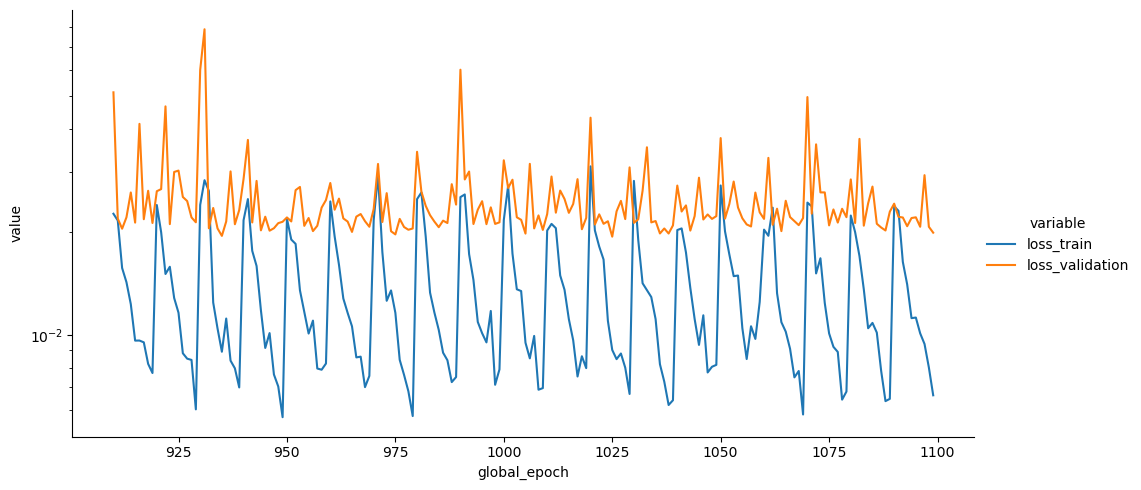

In [117]:
sns.relplot(
    losses_df.query(
        "n_samples == 5000 "
        "and energy_baseline == 250.0 "
        "and epochs == 10 "
        "and n_spins == 36 "
        "and net == 'LogProbDenseNet' "
        "and iteration > 90 and "
        "iteration < 110 "
        "and resample_every == 1"
    ).melt(id_vars='global_epoch', value_vars=['loss_train', 'loss_validation']),
    x="global_epoch",
    y="value",
    hue='variable',
    kind="line",
    aspect=2,
).set(yscale="log")

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


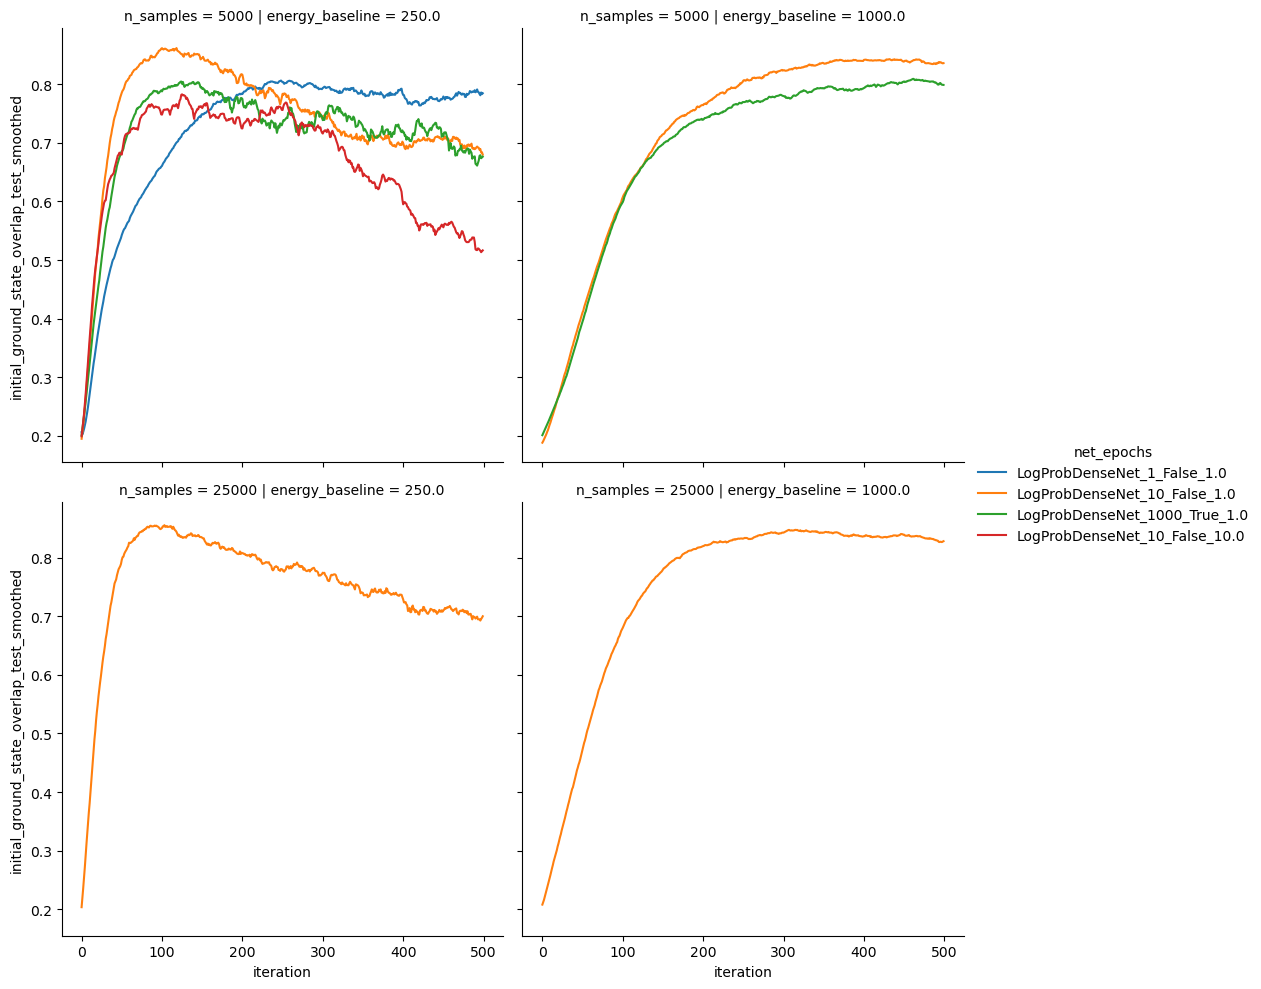

In [97]:
sns.relplot(
    data=overlaps_df.query("n_spins == 36").dropna(subset='energy')
    .assign(
        initial_ground_state_overlap_test_smoothed=lambda df: df.groupby(params)[
            "initial_ground_state_overlap_test"
        ].transform(lambda x: x.rolling(window=1, center=True).mean()),
        net_epochs=concat_columns(["net", "epochs", "early_stop", "resample_every"]),
    )
    .pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
    x="iteration",
    y="initial_ground_state_overlap_test_smoothed",
    # col="epochs",
    hue="net_epochs",
    col="energy_baseline",
    kind="line",
    row="n_samples"
)

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


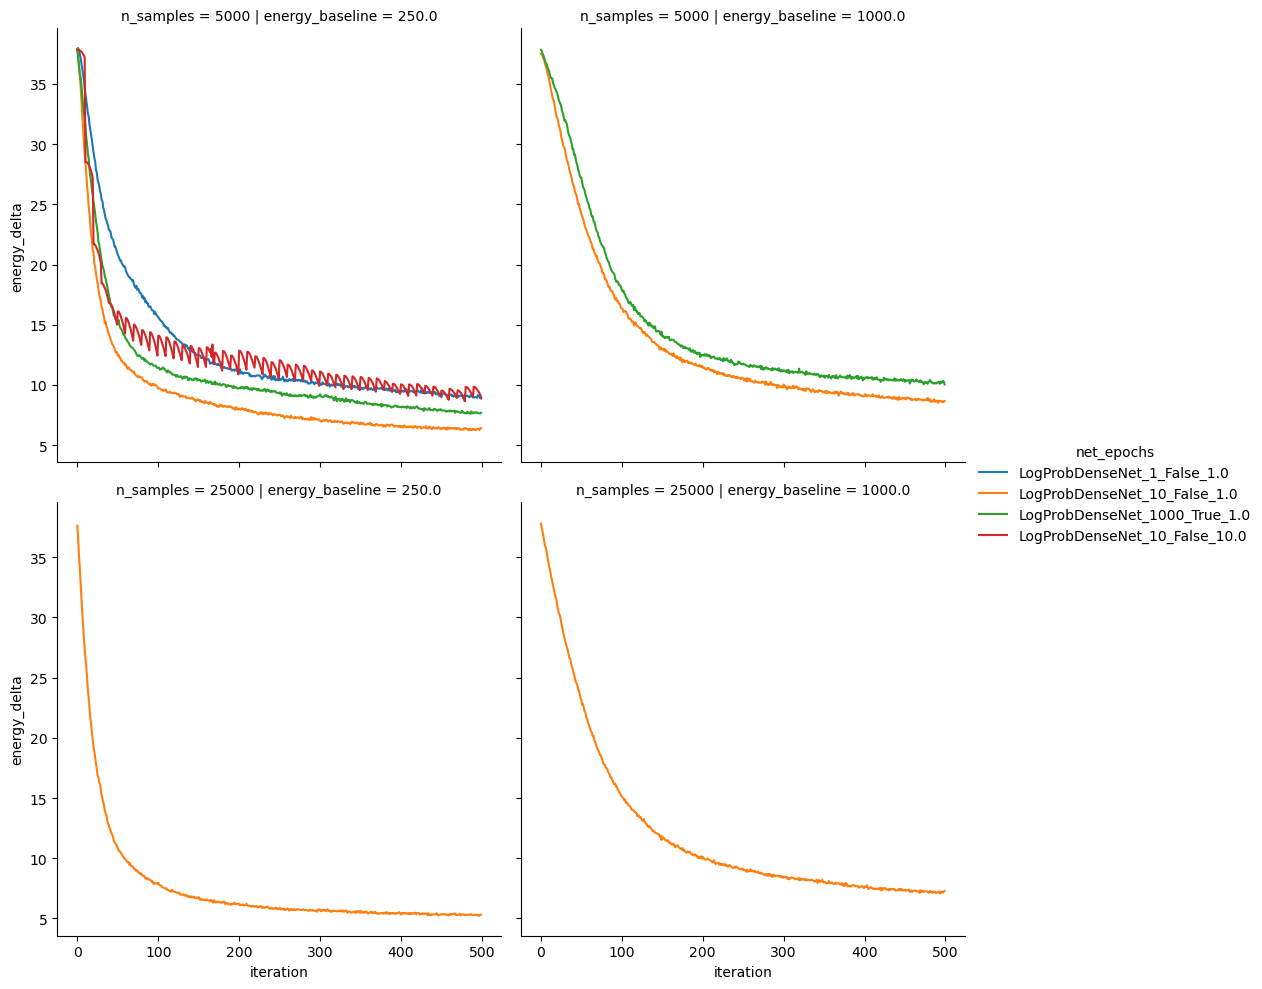

In [98]:
sns.relplot(
    overlaps_df.query("n_spins == 36")
    .dropna(subset="energy")
    .assign(
        net_epochs=concat_columns(["net", "epochs", "early_stop", "resample_every"]),
        energy_delta=lambda df: -true_energy - df["energy"] + df["energy_baseline"],
    ),
    x="iteration",
    # y="loc_energy_std",
    y="energy_delta",
    hue="net_epochs",
    col="energy_baseline",
    kind="line",
    row="n_samples",
    # no share y
    # facet_kws=dict(sharey=False)
)

In [91]:
overlaps_df.query("n_spins == 36").assign(net_epochs=concat_columns(["net", "epochs", "early_stop", "resample_every"]))['energy']

50      275.345338
51      275.145701
52      275.346849
53      275.666340
54      275.948628
           ...    
4949    306.756070
4950    306.794675
4951    306.878403
4952    306.729136
4953    306.715227
Name: energy, Length: 4148, dtype: float64

In [92]:
overlaps_df.query("n_spins == 36").dropna(subset='energy').assign(
        net_epochs=concat_columns(["net", "epochs", "early_stop", "resample_every"])
    ).groupby(['iteration', 'net_epochs', 'n_samples', 'energy_baseline'])['energy'].mean()

iteration  net_epochs                     n_samples  energy_baseline
0          LogProbDenseNet_1000_True_1.0  5000       250.0               275.206305
                                                     1000.0             1025.292409
           LogProbDenseNet_10_False_1.0   5000       250.0               275.204617
                                                     1000.0             1025.628496
                                          25000      250.0               275.495907
                                                                           ...     
499        LogProbDenseNet_10_False_1.0   5000       1000.0             1054.465400
                                          25000      250.0               307.808321
                                                     1000.0             1055.847991
           LogProbDenseNet_10_False_10.0  5000       250.0               304.145191
           LogProbDenseNet_1_False_1.0    5000       250.0               304.250255
Name: e

KeyError: 'y'

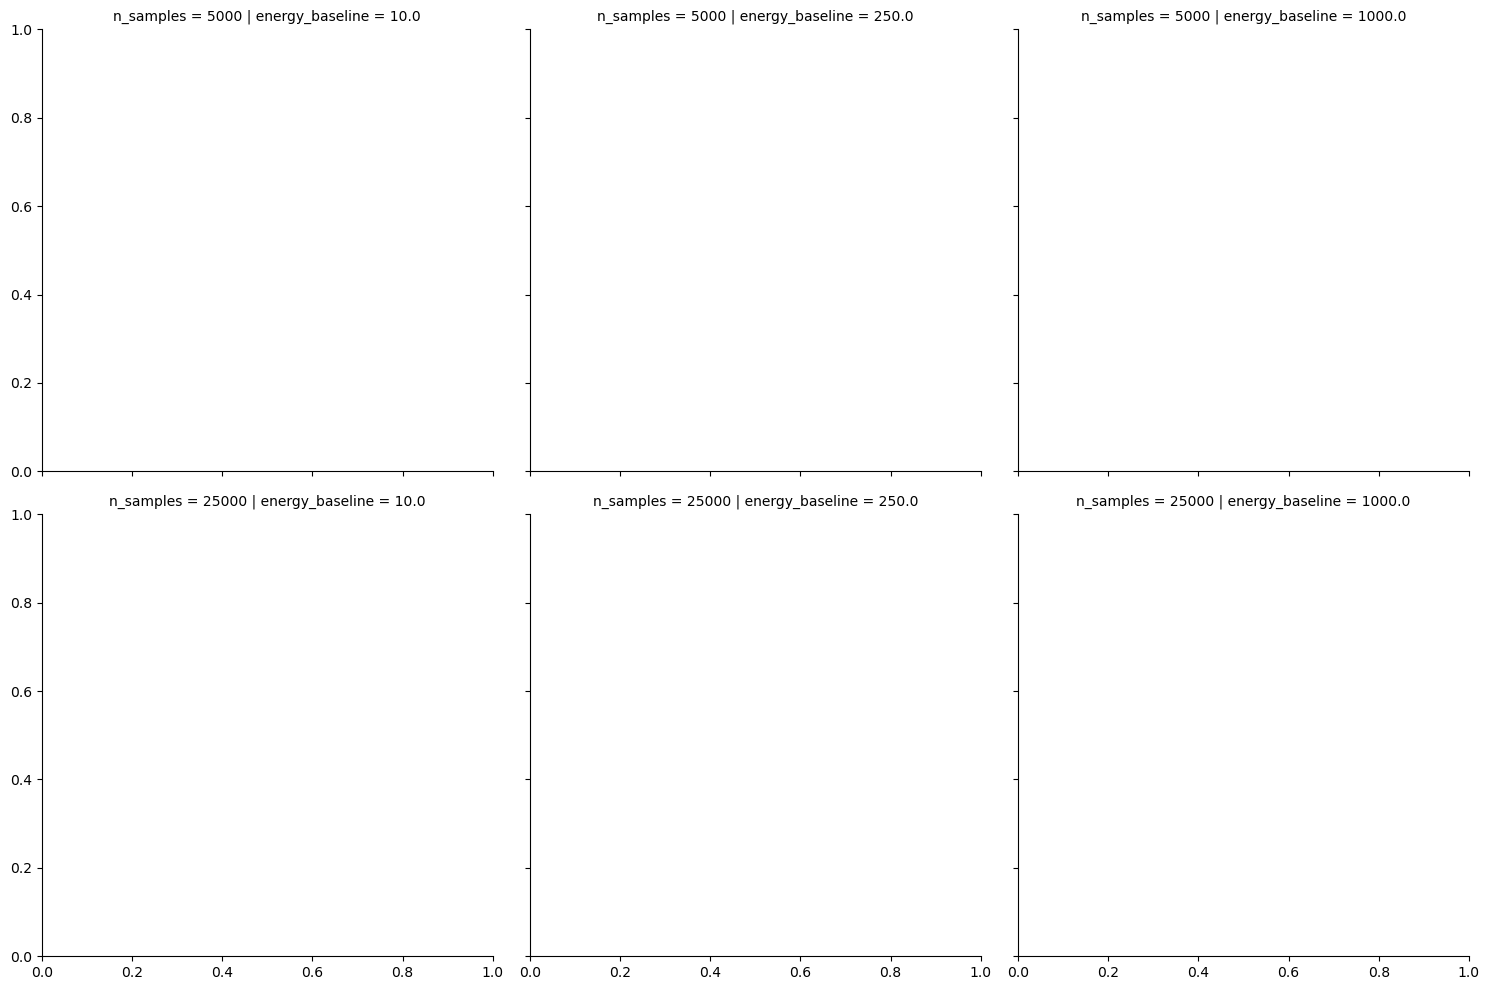

In [93]:
sns.relplot(
    data=overlaps_df.query("n_spins == 36").assign(net_epochs=concat_columns(["net", "epochs", "early_stop", "resample_every"])),
    x="iteration",
    y="energy",
    # col="epochs",
    hue="net_epochs",
    col="energy_baseline",
    kind="line",
    row="n_samples"
)

In [ ]:
overlaps_df.query('n_spins == 36').groupby(params)['initial_ground_state_overlap_test'].quantile(0.95)

n_spins  n_samples  energy_baseline  epochs  net              reset_network  use_symmetries  resample_every
36       5000       10.0             100     LogProbDenseNet  False          True            1.0               0.738201
                    250.0            1       LogProbDenseNet  False          True            1.0               0.802558
                                     10      LogProbDenseNet  False          True            1.0               0.855520
                                                                                             10.0              0.764520
                                     100     LogProbDenseNet  False          True            1.0               0.737434
                                     1000    LogProbDenseNet  False          True            1.0               0.798613
                    1000.0           10      LogProbDenseNet  False          True            1.0               0.841515
                                     1000    LogProb

In [ ]:
# (ggplot(overlaps_df.dropna(subset=['energy_baseline']), aes(x='iteration', y='new_ground_state_overlap_test', color='energy_baseline'))
#     + geom_point() + geom_smooth(method='loess')
#     + facet_grid('n_samples ~ lattice') + theme_minimal())

In [ ]:
# sns.relplot(
#     overlaps_df.query("lattice == 'KagomeLattice2x3'").pipe(to_cat("energy_baseline")),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="energy_baseline",
#     kind="line",
#     row="lattice",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')


In [ ]:
# sns.relplot(
#     overlaps_df.query("mode == 'power'"),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="lattice",
#     kind="line",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')


/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


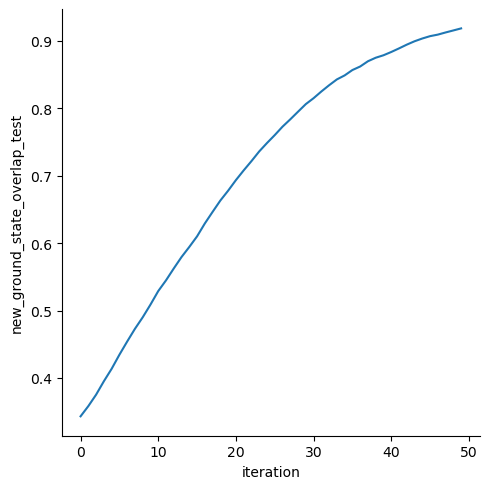

In [4]:
sns.relplot(overlaps_df.query('task_id == 30'), x='iteration', y='new_ground_state_overlap_test', kind='line')

In [5]:
lattice, _ = get_kagome27()
system = HeisenbergJ1J2(lattice=lattice, use_symmetries=True, skip_symmetries_whitelist=True)
net = LogProbDenseNet(system, n_hidden=512)

2023-09-18 19:54:17.964 | WARNING  | heisenberg_hamiltonians:__init__:430 - Symmetries are not tested with KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-09-18 19:54:17.972 | DEBUG    | heisenberg_hamiltonians:__init__:462 - number_spins=27
2023-09-18 19:54:18.183 | DEBUG    | heisenberg_hamiltonians:__init__:472 - Symmetry group contains 216 elements
2023-09-18 19:54:18.186 | DEBUG    | heisenberg_hamiltonians:__init__:473 - Constructing basis
2023-09-18 19:54:19.046 | DEBUG    | heisenberg_hamiltonians:__init__:481 - Hilbert space dimension is 93610


In [82]:
energy, ground_state = system.get_eigenstates(1)
ground_state = ground_state[:, 0]

In [169]:
# load net from checkpoint
net.load_state_dict(torch.load(output_dir / '30' / 'log_prob_fn_30.pt'))

<All keys matched successfully>

In [170]:
net(system.basis.states)

tensor([[-1.1627],
        [-1.3891],
        [ 0.4637],
        ...,
        [ 9.1857],
        [ 9.2016],
        [ 7.9306]], grad_fn=<MulBackward0>)

In [176]:
predicted_amplitudes = torch.exp(net(system.basis.states) * 0.5)
# predicted_amplitudes = (predicted_amplitudes / torch.sqrt((predicted_amplitudes ** 2).sum())).view(-1).detach().numpy()
predicted_amplitudes = (predicted_amplitudes / torch.sqrt((predicted_amplitudes ** 2).sum())).view(-1).detach().numpy()
predicted_amplitudes

array([6.5776061e-05, 5.8735619e-05, 1.4833137e-04, ..., 1.1619762e-02,
       1.1712215e-02, 6.2037343e-03], dtype=float32)

In [177]:
errors = np.abs(np.log(np.abs(predicted_amplitudes)) - np.log(np.abs(ground_state)))

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


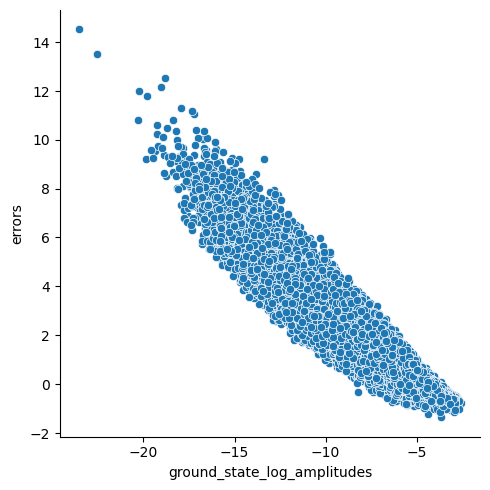

In [186]:
sns.relplot(
    pd.DataFrame(
        dict(
            predicted_log_amplitudes=np.log(predicted_amplitudes),
            ground_state_log_amplitudes=np.log(np.abs(ground_state)),
        )
    ).assign(
        errors=lambda df: (df["predicted_log_amplitudes"] - df["ground_state_log_amplitudes"])
    ),
    x="ground_state_log_amplitudes",
    y="errors",
    kind="scatter",
)

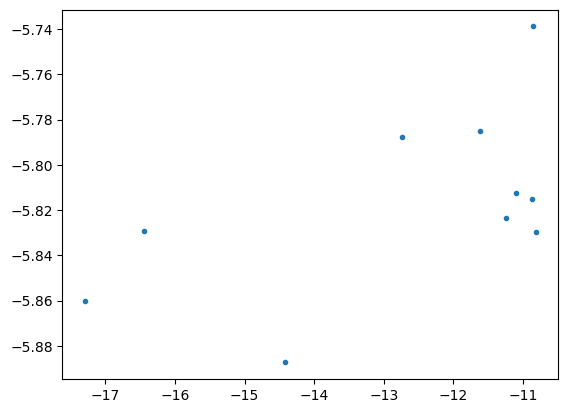

In [92]:
plt.plot(np.log(np.abs(ground_state))[:10], np.log((predicted_amplitudes))[:10], '.')

In [72]:
np.log(np.abs(ground_state))

array([-16.45076715, -17.29595219, -11.09596661, ...,  -5.79090536,
        -8.76950877,  -8.07636159])

In [73]:
errors

array([2.80037265, 2.85047298, 2.40658345, ..., 1.75843683, 2.1720755 ,
       2.08939469])

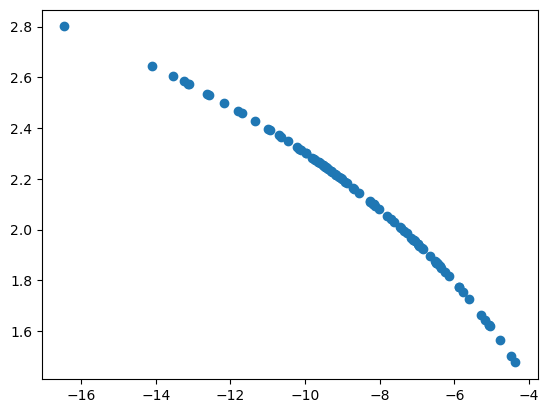

In [78]:
plt.plot(np.log(np.abs(ground_state))[::1000], errors[::1000], 'o')